# CS584 - Assignment 4 (Transformers)
**IMDB Sentiment Classification with Transformer Architectures**

In [1]:
!pip install -q keras-nlp keras-hub tokenizers sentencepiece


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score
import seaborn as sns
import time

# Try current package first, then older one
try:
    import keras_hub
    TransformerEncoderLayer = keras_hub.layers.TransformerEncoder
    print("Using keras_hub.layers.TransformerEncoder")
except (ImportError, AttributeError):
    try:
        import keras_nlp
        TransformerEncoderLayer = keras_nlp.layers.TransformerEncoder
        print("Using keras_nlp.layers.TransformerEncoder")
    except ImportError:
        raise ImportError("Please install keras-hub or keras-nlp: pip install keras-hub")

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

Using keras_hub.layers.TransformerEncoder
TensorFlow version: 2.20.0
Keras version: 3.14.0


---
## Problem 1: Dataset Preparation

In [3]:
# ============================
# Configuration
# ============================
max_features = 20000    # Vocabulary size (restrict to top 20,000 words)
maxlen = 200            # Pad/truncate sequences to fixed length
embed_dim = 64          # Embedding dimension
num_heads = 2           # Number of attention heads
ff_dim = 64             # Feedforward network dimension

In [4]:
# ============================
# 1. Load IMDB dataset
# ============================
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(
    num_words=max_features
)

print(f"Training samples: {len(x_train)}")
print(f"Test samples: {len(x_test)}")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/Users/ayaan/Library/Mobile Documents/com~apple~CloudDocs/College/SPRING26/CS584/HW4/hw4env/lib/python3.12/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Training samples: 25000
Test samples: 25000


In [5]:
# ============================
# 2. Pad sequences to fixed length
# ============================
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen)

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

x_train shape: (25000, 200)
x_test shape: (25000, 200)


In [6]:
# ============================
# 3. Split training into train/validation (80/20)
# ============================
val_split = 0.2
num_val = int(len(x_train) * val_split)

# Shuffle with fixed seed for reproducibility
indices = np.arange(len(x_train))
np.random.seed(42)
np.random.shuffle(indices)

x_train_shuffled = x_train[indices]
y_train_shuffled = y_train[indices]

x_val = x_train_shuffled[:num_val]
y_val = y_train_shuffled[:num_val]
x_train_final = x_train_shuffled[num_val:]
y_train_final = y_train_shuffled[num_val:]

print(f"Training set: {x_train_final.shape[0]} samples")
print(f"Validation set: {x_val.shape[0]} samples")
print(f"Test set: {x_test.shape[0]} samples")

Training set: 20000 samples
Validation set: 5000 samples
Test set: 25000 samples


In [7]:
# ============================
# 4. Report dataset statistics
# ============================
# Sequence length statistics (before padding)
(x_raw_train, _), (x_raw_test, _) = keras.datasets.imdb.load_data(num_words=max_features)
all_lengths = [len(seq) for seq in x_raw_train] + [len(seq) for seq in x_raw_test]
train_lengths = [len(seq) for seq in x_raw_train]
test_lengths = [len(seq) for seq in x_raw_test]

print("=== Dataset Statistics ===")
print(f"Vocabulary size: {max_features}")
print(f"Padded sequence length: {maxlen}")
print(f"")
print(f"Split sizes:")
print(f"  Train: {len(x_train_final)} samples")
print(f"  Validation: {len(x_val)} samples")
print(f"  Test: {len(x_test)} samples")
print(f"")
print(f"Sequence length statistics (before padding):")
print(f"  Mean: {np.mean(all_lengths):.1f}")
print(f"  Median: {np.median(all_lengths):.1f}")
print(f"  Min: {np.min(all_lengths)}")
print(f"  Max: {np.max(all_lengths)}")
print(f"  Std: {np.std(all_lengths):.1f}")
print(f"")
print(f"Label distribution (train): Pos={np.sum(y_train_final==1)}, Neg={np.sum(y_train_final==0)}")
print(f"Label distribution (val):   Pos={np.sum(y_val==1)}, Neg={np.sum(y_val==0)}")
print(f"Label distribution (test):  Pos={np.sum(y_test==1)}, Neg={np.sum(y_test==0)}")

=== Dataset Statistics ===
Vocabulary size: 20000
Padded sequence length: 200

Split sizes:
  Train: 20000 samples
  Validation: 5000 samples
  Test: 25000 samples

Sequence length statistics (before padding):
  Mean: 234.8
  Median: 176.0
  Min: 7
  Max: 2494
  Std: 172.9

Label distribution (train): Pos=9937, Neg=10063
Label distribution (val):   Pos=2563, Neg=2437
Label distribution (test):  Pos=12500, Neg=12500


---
## Problem 2: Transformer with Keras (Baseline)

Build a Transformer-based classifier using a prebuilt Transformer encoder. The model includes: token embedding, positional embedding, one or more TransformerEncoder layers, pooling, and a dense classification head.

In [8]:
# ============================
# Token + Positional Embedding (provided)
# ============================
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        seq_len = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        position_embeddings = self.pos_emb(positions)
        token_embeddings = self.token_emb(x)
        return token_embeddings + position_embeddings

In [9]:
# ============================
# Build baseline model using prebuilt TransformerEncoder
# ============================
def build_model_builtin(num_encoder_layers=1):
    inputs = layers.Input(shape=(maxlen,))
    x = TokenAndPositionEmbedding(maxlen, max_features, embed_dim)(inputs)

    # Use one or more prebuilt TransformerEncoder layers
    for _ in range(num_encoder_layers):
        x = TransformerEncoderLayer(
            intermediate_dim=ff_dim,
            num_heads=num_heads,
            dropout=0.1,
        )(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(20, activation="relu")(x)
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    return keras.Model(inputs, outputs)

In [10]:
# ============================
# Train the baseline model
# ============================
model_builtin = build_model_builtin(num_encoder_layers=1)
model_builtin.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
model_builtin.summary()

start_time = time.time()
history_builtin = model_builtin.fit(
    x_train_final, y_train_final,
    batch_size=32,
    epochs=10,
    validation_data=(x_val, y_val)
)
builtin_train_time = time.time() - start_time
print(f"\nTraining time: {builtin_train_time:.1f}s")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 200, 64)        │     1,292,800 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, 200, 64)        │        25,216 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,319,337 (5.03 MB)

 Trainable params: 1,319,337 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 35ms/step - accuracy: 0.7965 - loss: 0.4106 - val_accuracy: 0.8536 - val_loss: 0.3467
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.9268 - loss: 0.1960 - val_accuracy: 0.8822 - val_loss: 0.2860
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.9614 - loss: 0.1127 - val_accuracy: 0.8740 - val_loss: 0.3762
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.9796 - loss: 0.0627 - val_accuracy: 0.8574 - val_loss: 0.5182
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.9891 - loss: 0.0362 - val_accuracy: 0.8514 - val_loss: 0.7332
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.9916 - loss: 0.0275 - val_accuracy: 0.8586 - val_loss: 0.6558
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.9926 - loss: 0.0221 - val_accuracy: 0.8576 - val_loss: 0.9373
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.9942 - loss: 0.0157 - 

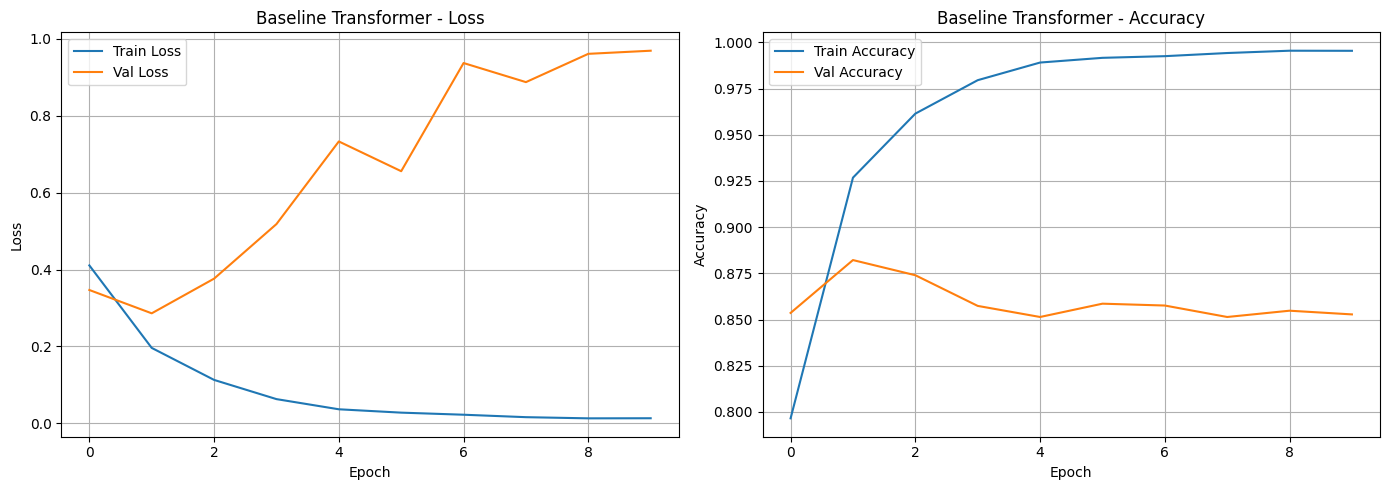

In [11]:
# ============================
# Plot training/validation loss and accuracy
# ============================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_builtin.history['loss'], label='Train Loss')
axes[0].plot(history_builtin.history['val_loss'], label='Val Loss')
axes[0].set_title('Baseline Transformer - Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history_builtin.history['accuracy'], label='Train Accuracy')
axes[1].plot(history_builtin.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Baseline Transformer - Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step
=== Baseline Transformer (Prebuilt) - Test Set Results ===
              precision    recall  f1-score   support

    Negative       0.84      0.82      0.83     12500
    Positive       0.82      0.85      0.84     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000

Accuracy: 0.8328
F1-Score: 0.8352


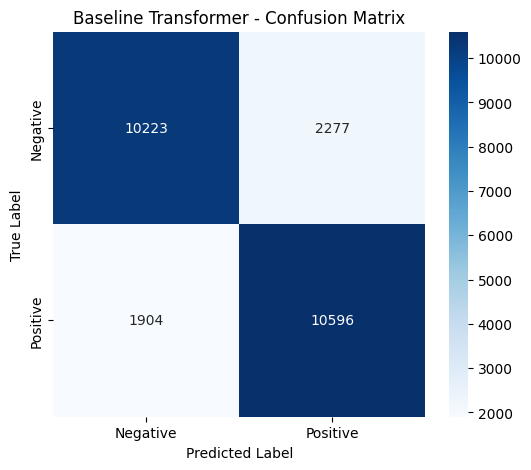

In [12]:
# ============================
# Evaluate on test set
# ============================
y_pred_builtin_prob = model_builtin.predict(x_test)
y_pred_builtin = (y_pred_builtin_prob > 0.5).astype(int).flatten()

print("=== Baseline Transformer (Prebuilt) - Test Set Results ===")
print(classification_report(y_test, y_pred_builtin, target_names=['Negative', 'Positive']))
print(f"Accuracy: {accuracy_score(y_test, y_pred_builtin):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_builtin):.4f}")

# Confusion matrix
cm_builtin = confusion_matrix(y_test, y_pred_builtin)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_builtin, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Baseline Transformer - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

---
## Problem 3: Custom Transformer Block Implementation

Manually implement the Transformer encoder block by replacing the prebuilt `TransformerEncoder` layer. The custom block includes:
- Multi-head self-attention
- Feedforward network (Dense -> ReLU -> Dense)
- Residual connections (skip connections)
- Layer normalization (after each residual addition)
- Dropout (after attention and feedforward sublayers)

Architecture: **Input -> Multi-Head Self-Attention -> Add and Norm -> Feedforward Network -> Add Norm -> Output**

In [13]:
# ============================
# Custom Transformer Encoder Block
# ============================
class TransformerEncoderBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()

        # Multi-head self-attention
        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim,
        )

        # Feedforward network
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])

        # Layer normalization
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)

        # Dropout
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=None):
        # 1. Multi-head self-attention
        attn_output = self.att(inputs, inputs)
        # 2. Dropout on attention output
        attn_output = self.dropout1(attn_output, training=training)
        # 3. Residual connection + layer normalization
        out1 = self.layernorm1(inputs + attn_output)
        # 4. Feedforward network
        ffn_output = self.ffn(out1)
        # 5. Dropout on feedforward output
        ffn_output = self.dropout2(ffn_output, training=training)
        # 6. Residual connection + layer normalization
        out2 = self.layernorm2(out1 + ffn_output)
        return out2

In [14]:
# ============================
# Build model with custom Transformer block
# ============================
def build_model_custom(num_encoder_layers=1):
    inputs = layers.Input(shape=(maxlen,))
    x = TokenAndPositionEmbedding(maxlen, max_features, embed_dim)(inputs)

    for _ in range(num_encoder_layers):
        x = TransformerEncoderBlock(embed_dim, num_heads, ff_dim)(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(20, activation="relu")(x)
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    return keras.Model(inputs, outputs)

In [15]:
# ============================
# Train the custom model
# ============================
model_custom = build_model_custom(num_encoder_layers=1)
model_custom.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
model_custom.summary()

start_time = time.time()
history_custom = model_custom.fit(
    x_train_final, y_train_final,
    batch_size=32,
    epochs=10,
    validation_data=(x_val, y_val)
)
custom_train_time = time.time() - start_time
print(f"\nTraining time: {custom_train_time:.1f}s")

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_1  │ (None, 200, 64)        │     1,292,800 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_block       │ (None, 200, 64)        │        41,792 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,335,913 (5.10 MB)

 Trainable params: 1,335,913 (5.10 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.7998 - loss: 0.4065 - val_accuracy: 0.8848 - val_loss: 0.2714
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - accuracy: 0.9268 - loss: 0.1972 - val_accuracy: 0.8800 - val_loss: 0.2921
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - accuracy: 0.9611 - loss: 0.1135 - val_accuracy: 0.8740 - val_loss: 0.3937
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.9794 - loss: 0.0637 - val_accuracy: 0.8688 - val_loss: 0.4419
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.9865 - loss: 0.0422 - val_accuracy: 0.8610 - val_loss: 0.6584
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.9916 - loss: 0.0282 - val_accuracy: 0.8560 - val_loss: 0.6360
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.9929 - loss: 0.0225 - val_accuracy: 0.8584 - val_loss: 0.7763
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - accuracy: 0.9944 - loss: 0.0160 - 

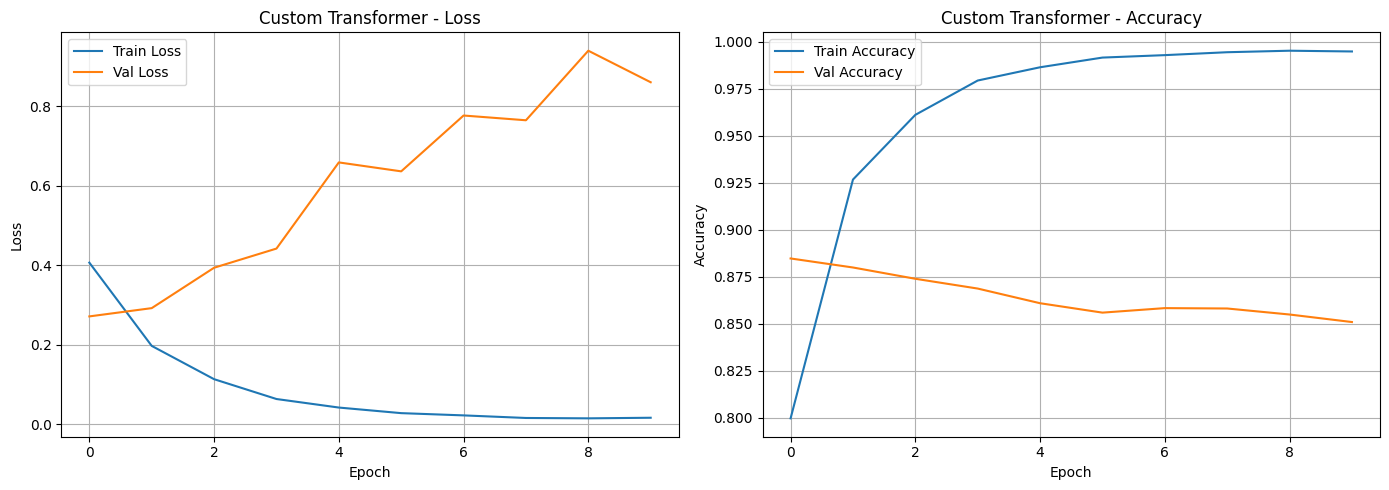

In [16]:
# ============================
# Plot training/validation loss and accuracy
# ============================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_custom.history['loss'], label='Train Loss')
axes[0].plot(history_custom.history['val_loss'], label='Val Loss')
axes[0].set_title('Custom Transformer - Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_custom.history['accuracy'], label='Train Accuracy')
axes[1].plot(history_custom.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Custom Transformer - Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step
=== Custom Transformer - Test Set Results ===
              precision    recall  f1-score   support

    Negative       0.84      0.82      0.83     12500
    Positive       0.83      0.84      0.83     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000

Accuracy: 0.8308
F1-Score: 0.8322


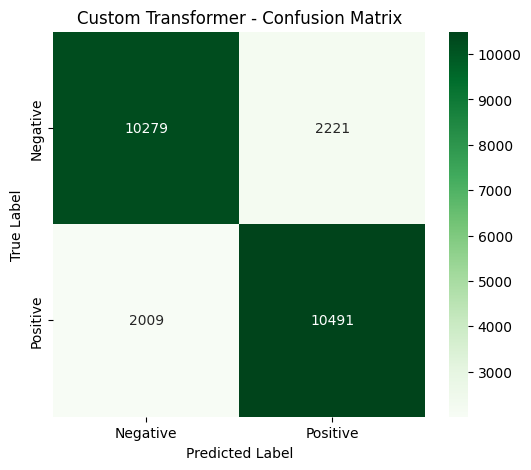

In [17]:
# ============================
# Evaluate on test set
# ============================
y_pred_custom_prob = model_custom.predict(x_test)
y_pred_custom = (y_pred_custom_prob > 0.5).astype(int).flatten()

print("=== Custom Transformer - Test Set Results ===")
print(classification_report(y_test, y_pred_custom, target_names=['Negative', 'Positive']))
print(f"Accuracy: {accuracy_score(y_test, y_pred_custom):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_custom):.4f}")

# Confusion matrix
cm_custom = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Custom Transformer - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

---
## Problem 4: Comparison Study

Compare the Keras-based Transformer (Part 2) and Custom Transformer block (Part 3).

In [18]:
# ============================
# Side-by-side comparison
# ============================
builtin_params = model_builtin.count_params()
custom_params = model_custom.count_params()

builtin_test_acc = accuracy_score(y_test, y_pred_builtin)
custom_test_acc = accuracy_score(y_test, y_pred_custom)

builtin_val_acc = max(history_builtin.history['val_accuracy'])
custom_val_acc = max(history_custom.history['val_accuracy'])

builtin_train_acc = max(history_builtin.history['accuracy'])
custom_train_acc = max(history_custom.history['accuracy'])

print("=" * 65)
print(f"{'Metric':<30} {'Builtin':>15} {'Custom':>15}")
print("=" * 65)
print(f"{'Total Parameters':<30} {builtin_params:>15,} {custom_params:>15,}")
print(f"{'Training Time (s)':<30} {builtin_train_time:>15.1f} {custom_train_time:>15.1f}")
print(f"{'Best Train Accuracy':<30} {builtin_train_acc:>15.4f} {custom_train_acc:>15.4f}")
print(f"{'Best Val Accuracy':<30} {builtin_val_acc:>15.4f} {custom_val_acc:>15.4f}")
print(f"{'Test Accuracy':<30} {builtin_test_acc:>15.4f} {custom_test_acc:>15.4f}")
print(f"{'Test F1-Score':<30} {f1_score(y_test, y_pred_builtin):>15.4f} {f1_score(y_test, y_pred_custom):>15.4f}")
print(f"{'Test Precision':<30} {precision_score(y_test, y_pred_builtin):>15.4f} {precision_score(y_test, y_pred_custom):>15.4f}")
print(f"{'Test Recall':<30} {recall_score(y_test, y_pred_builtin):>15.4f} {recall_score(y_test, y_pred_custom):>15.4f}")
print("=" * 65)

Metric                                 Builtin          Custom
Total Parameters                     1,319,337       1,335,913
Training Time (s)                        234.7           268.9
Best Train Accuracy                     0.9955          0.9952
Best Val Accuracy                       0.8822          0.8848
Test Accuracy                           0.8328          0.8308
Test F1-Score                           0.8352          0.8322
Test Precision                          0.8231          0.8253
Test Recall                             0.8477          0.8393


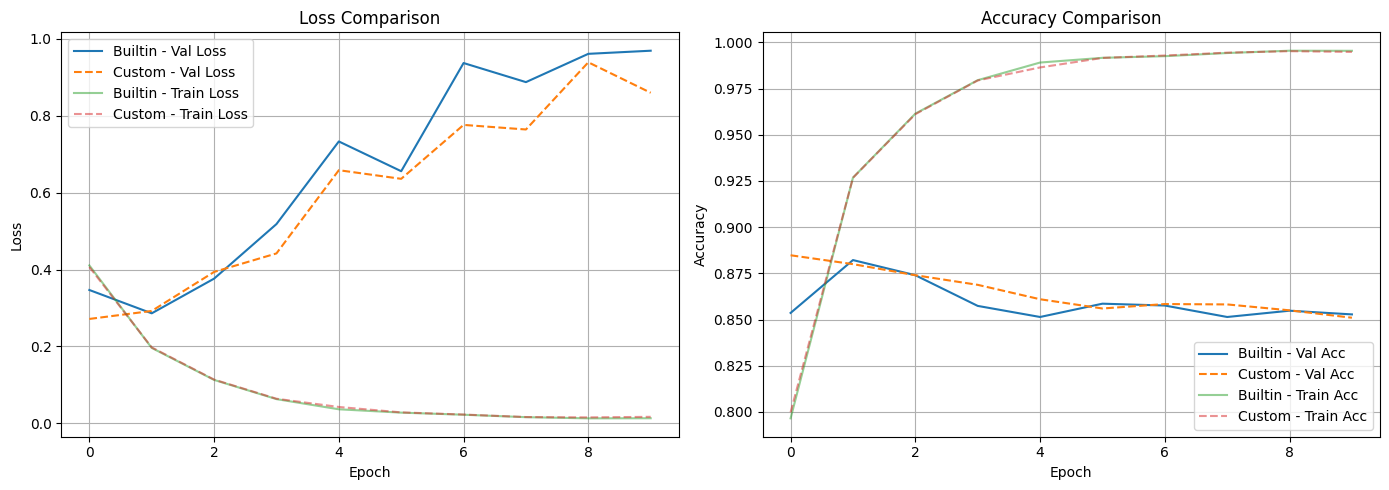

In [19]:
# ============================
# Comparison plots
# ============================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
axes[0].plot(history_builtin.history['val_loss'], label='Builtin - Val Loss', linestyle='-')
axes[0].plot(history_custom.history['val_loss'], label='Custom - Val Loss', linestyle='--')
axes[0].plot(history_builtin.history['loss'], label='Builtin - Train Loss', linestyle='-', alpha=0.5)
axes[0].plot(history_custom.history['loss'], label='Custom - Train Loss', linestyle='--', alpha=0.5)
axes[0].set_title('Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy comparison
axes[1].plot(history_builtin.history['val_accuracy'], label='Builtin - Val Acc', linestyle='-')
axes[1].plot(history_custom.history['val_accuracy'], label='Custom - Val Acc', linestyle='--')
axes[1].plot(history_builtin.history['accuracy'], label='Builtin - Train Acc', linestyle='-', alpha=0.5)
axes[1].plot(history_custom.history['accuracy'], label='Custom - Train Acc', linestyle='--', alpha=0.5)
axes[1].set_title('Accuracy Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Discussion

**1. What functionality does the built-in implementation provide automatically?**

The prebuilt `TransformerEncoder` from keras_nlp/keras_hub automatically handles:
- Multi-head self-attention computation with proper scaling
- Feedforward network with configurable intermediate dimension
- Residual (skip) connections around both sublayers
- Layer normalization after each sublayer
- Dropout regularization
- Proper masking support for variable-length sequences
- Efficient kernel initialization and weight management

This encapsulates the entire Transformer encoder block into a single configurable layer, reducing boilerplate and potential implementation errors.

**2. Where are residual connections implemented in the custom block?**

The custom `TransformerEncoderBlock` implements two residual connections:
1. **After self-attention**: The input is added to the attention output before layer normalization: `out1 = LayerNorm(inputs + Dropout(Attention(inputs)))`. This allows the gradient to flow directly through the skip connection.
2. **After feedforward network**: The attention sublayer output is added to the feedforward output: `out2 = LayerNorm(out1 + Dropout(FFN(out1)))`. This preserves the representation from the attention stage.

These residual connections are critical for training deep Transformers, as they mitigate the vanishing gradient problem and allow the model to learn identity mappings when needed.

**3. Why do the models perform similarly or differently?**

Both models should perform similarly because they implement the same Transformer encoder architecture. The built-in layer uses the same core operations (multi-head attention, feedforward, residual + norm). Minor differences in performance can arise from:
- Different weight initialization defaults
- Slightly different normalization placement (pre-norm vs. post-norm)
- Built-in optimizations like fused kernels in the prebuilt version
- Random seed differences across runs

**4. Which implementation would you prefer in practice and why?**

For production use, the **built-in implementation** is preferred because it is well-tested, optimized, and maintained by the Keras team. It handles edge cases (masking, serialization) automatically and reduces the surface area for bugs.

However, the **custom implementation** is valuable for:
- Research and experimentation with non-standard architectures
- Educational purposes to understand Transformer internals
- Situations requiring modifications not supported by the prebuilt API (e.g., custom attention patterns, different normalization strategies)

---
## Problem 5: Parameter Study

Evaluate the effect of varying:
1. Embedding dimension
2. Number of attention heads
3. Sequence length
4. Feedforward dimension

In [20]:
# ============================
# Helper: train and evaluate a custom model with given hyperparameters
# ============================
def train_and_evaluate(embed_dim_p, num_heads_p, ff_dim_p, maxlen_p,
                       x_tr, y_tr, x_v, y_v, x_te, y_te, epochs=5):
    """Train a custom Transformer model with given hyperparameters and return metrics."""
    # Pad to the specified maxlen
    x_tr_pad = keras.preprocessing.sequence.pad_sequences(x_tr, maxlen=maxlen_p) if maxlen_p != x_tr.shape[1] else x_tr
    x_v_pad = keras.preprocessing.sequence.pad_sequences(x_v, maxlen=maxlen_p) if maxlen_p != x_v.shape[1] else x_v
    x_te_pad = keras.preprocessing.sequence.pad_sequences(x_te, maxlen=maxlen_p) if maxlen_p != x_te.shape[1] else x_te

    # Build model
    inp = layers.Input(shape=(maxlen_p,))
    x = TokenAndPositionEmbedding(maxlen_p, max_features, embed_dim_p)(inp)
    x = TransformerEncoderBlock(embed_dim_p, num_heads_p, ff_dim_p)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(20, activation="relu")(x)
    x = layers.Dropout(0.1)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inp, out)

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    start = time.time()
    history = model.fit(
        x_tr_pad, y_tr,
        batch_size=32,
        epochs=epochs,
        validation_data=(x_v_pad, y_v),
        verbose=0
    )
    train_time = time.time() - start

    y_pred = (model.predict(x_te_pad, verbose=0) > 0.5).astype(int).flatten()
    test_acc = accuracy_score(y_te, y_pred)
    test_f1 = f1_score(y_te, y_pred)
    val_acc = max(history.history['val_accuracy'])
    num_params = model.count_params()

    return {
        'test_acc': test_acc,
        'test_f1': test_f1,
        'val_acc': val_acc,
        'train_time': train_time,
        'num_params': num_params,
        'history': history
    }

In [21]:
# We need raw (unpadded) data for the sequence length experiment
(x_raw_tr, y_raw_tr), (x_raw_te, y_raw_te) = keras.datasets.imdb.load_data(num_words=max_features)

# Apply the same train/val split
x_raw_tr_shuffled = [x_raw_tr[i] for i in indices]
y_raw_tr_shuffled = y_raw_tr[indices]

x_raw_val = x_raw_tr_shuffled[:num_val]
y_raw_val = y_raw_tr_shuffled[:num_val]
x_raw_train_final = x_raw_tr_shuffled[num_val:]
y_raw_train_final = y_raw_tr_shuffled[num_val:]

/Users/ayaan/Library/Mobile Documents/com~apple~CloudDocs/College/SPRING26/CS584/HW4/hw4env/lib/python3.12/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [22]:
# ============================
# 5.1 Vary Embedding Dimension
# ============================
print("=== Varying Embedding Dimension ===")
embed_dims = [32, 64, 128, 256]
embed_results = {}

for ed in embed_dims:
    print(f"  Training with embed_dim={ed}...")
    embed_results[ed] = train_and_evaluate(
        embed_dim_p=ed, num_heads_p=2, ff_dim_p=64, maxlen_p=200,
        x_tr=x_train_final, y_tr=y_train_final,
        x_v=x_val, y_v=y_val,
        x_te=x_test, y_te=y_test
    )
    print(f"    Test Acc: {embed_results[ed]['test_acc']:.4f}, "
          f"Val Acc: {embed_results[ed]['val_acc']:.4f}, "
          f"Params: {embed_results[ed]['num_params']:,}, "
          f"Time: {embed_results[ed]['train_time']:.1f}s")

=== Varying Embedding Dimension ===
  Training with embed_dim=32...
    Test Acc: 0.8463, Val Acc: 0.8772, Params: 659,817, Time: 77.9s
  Training with embed_dim=64...
    Test Acc: 0.8420, Val Acc: 0.8834, Params: 1,335,913, Time: 135.5s
  Training with embed_dim=128...
    Test Acc: 0.8257, Val Acc: 0.8802, Params: 2,737,257, Time: 225.7s
  Training with embed_dim=256...
    Test Acc: 0.5000, Val Acc: 0.4874, Params: 5,736,553, Time: 375.1s


In [23]:
# ============================
# 5.2 Vary Number of Attention Heads
# ============================
print("=== Varying Number of Attention Heads ===")
head_counts = [1, 2, 4, 8]
head_results = {}

for nh in head_counts:
    print(f"  Training with num_heads={nh}...")
    head_results[nh] = train_and_evaluate(
        embed_dim_p=64, num_heads_p=nh, ff_dim_p=64, maxlen_p=200,
        x_tr=x_train_final, y_tr=y_train_final,
        x_v=x_val, y_v=y_val,
        x_te=x_test, y_te=y_test
    )
    print(f"    Test Acc: {head_results[nh]['test_acc']:.4f}, "
          f"Val Acc: {head_results[nh]['val_acc']:.4f}, "
          f"Params: {head_results[nh]['num_params']:,}, "
          f"Time: {head_results[nh]['train_time']:.1f}s")

=== Varying Number of Attention Heads ===
  Training with num_heads=1...
    Test Acc: 0.8398, Val Acc: 0.8774, Params: 1,319,337, Time: 93.7s
  Training with num_heads=2...
    Test Acc: 0.8242, Val Acc: 0.8836, Params: 1,335,913, Time: 129.6s
  Training with num_heads=4...
    Test Acc: 0.8302, Val Acc: 0.8848, Params: 1,369,065, Time: 204.8s
  Training with num_heads=8...
    Test Acc: 0.8435, Val Acc: 0.8834, Params: 1,435,369, Time: 326.3s


In [24]:
# ============================
# 5.3 Vary Sequence Length
# ============================
print("=== Varying Sequence Length ===")
seq_lengths = [50, 100, 200, 400]
seq_results = {}

for sl in seq_lengths:
    print(f"  Training with maxlen={sl}...")
    # Re-pad from raw sequences
    x_tr_sl = keras.preprocessing.sequence.pad_sequences(x_raw_train_final, maxlen=sl)
    x_v_sl = keras.preprocessing.sequence.pad_sequences(x_raw_val, maxlen=sl)
    x_te_sl = keras.preprocessing.sequence.pad_sequences(x_raw_te, maxlen=sl)

    seq_results[sl] = train_and_evaluate(
        embed_dim_p=64, num_heads_p=2, ff_dim_p=64, maxlen_p=sl,
        x_tr=x_tr_sl, y_tr=y_train_final,
        x_v=x_v_sl, y_v=y_val,
        x_te=x_te_sl, y_te=y_test
    )
    print(f"    Test Acc: {seq_results[sl]['test_acc']:.4f}, "
          f"Val Acc: {seq_results[sl]['val_acc']:.4f}, "
          f"Params: {seq_results[sl]['num_params']:,}, "
          f"Time: {seq_results[sl]['train_time']:.1f}s")

=== Varying Sequence Length ===
  Training with maxlen=50...
    Test Acc: 0.7746, Val Acc: 0.8156, Params: 1,326,313, Time: 40.9s
  Training with maxlen=100...
    Test Acc: 0.8138, Val Acc: 0.8542, Params: 1,329,513, Time: 69.2s
  Training with maxlen=200...
    Test Acc: 0.8401, Val Acc: 0.8862, Params: 1,335,913, Time: 113.8s
  Training with maxlen=400...
    Test Acc: 0.8532, Val Acc: 0.8904, Params: 1,348,713, Time: 227.7s


In [25]:
# ============================
# 5.4 Vary Feedforward Dimension
# ============================
print("=== Varying Feedforward Dimension ===")
ff_dims = [32, 64, 128, 256]
ff_results = {}

for fd in ff_dims:
    print(f"  Training with ff_dim={fd}...")
    ff_results[fd] = train_and_evaluate(
        embed_dim_p=64, num_heads_p=2, ff_dim_p=fd, maxlen_p=200,
        x_tr=x_train_final, y_tr=y_train_final,
        x_v=x_val, y_v=y_val,
        x_te=x_test, y_te=y_test
    )
    print(f"    Test Acc: {ff_results[fd]['test_acc']:.4f}, "
          f"Val Acc: {ff_results[fd]['val_acc']:.4f}, "
          f"Params: {ff_results[fd]['num_params']:,}, "
          f"Time: {ff_results[fd]['train_time']:.1f}s")

=== Varying Feedforward Dimension ===
  Training with ff_dim=32...
    Test Acc: 0.8401, Val Acc: 0.8730, Params: 1,331,785, Time: 107.0s
  Training with ff_dim=64...
    Test Acc: 0.8405, Val Acc: 0.8808, Params: 1,335,913, Time: 110.2s
  Training with ff_dim=128...
    Test Acc: 0.8322, Val Acc: 0.8726, Params: 1,344,169, Time: 114.6s
  Training with ff_dim=256...
    Test Acc: 0.8356, Val Acc: 0.8830, Params: 1,360,681, Time: 119.6s


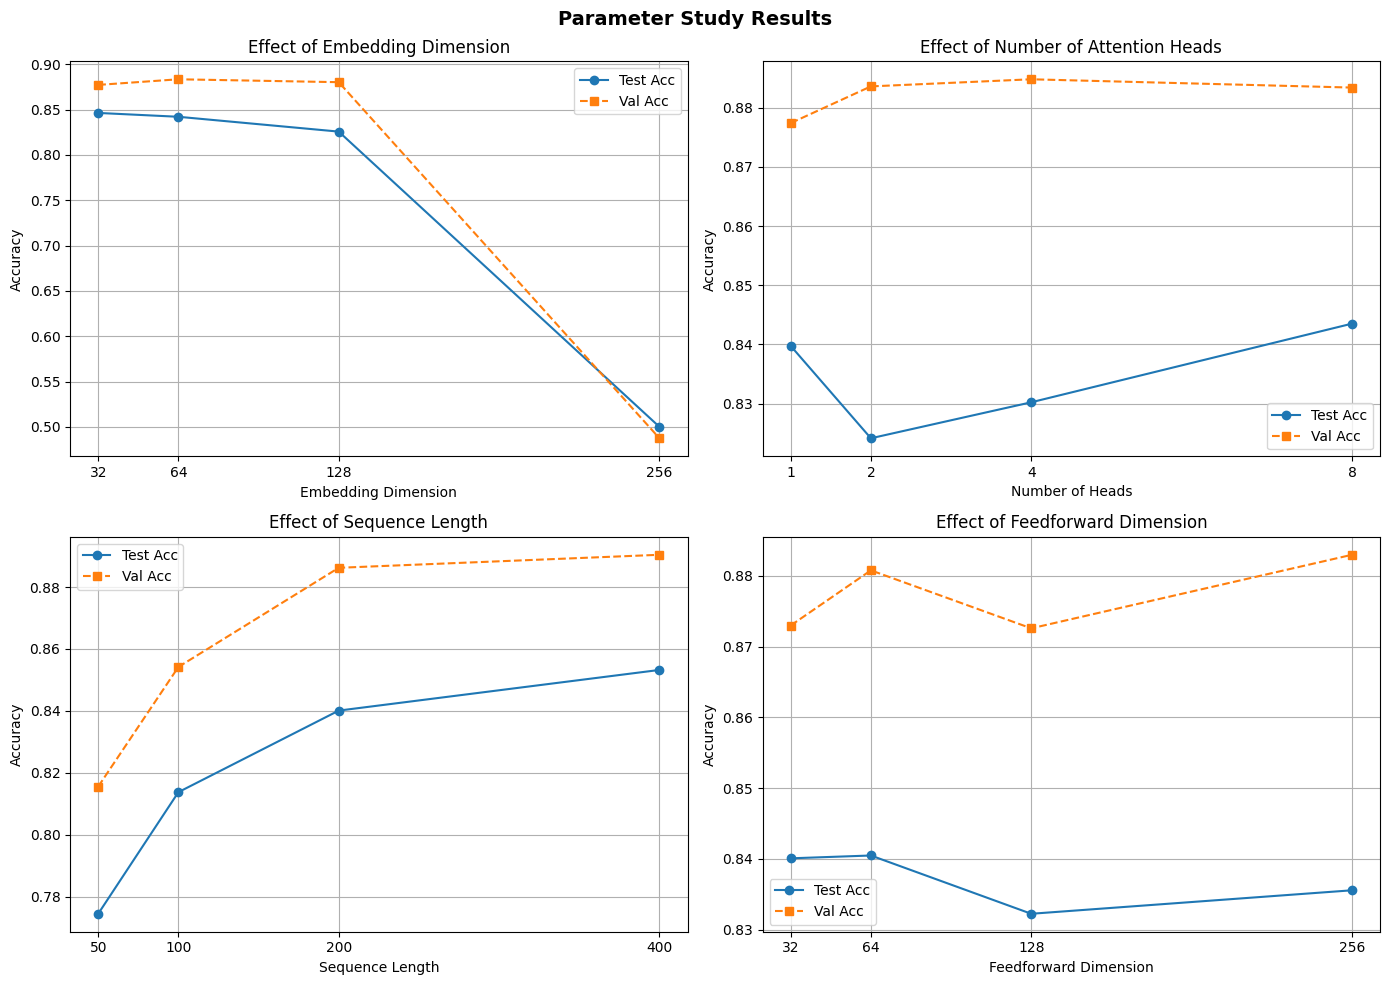

In [26]:
# ============================
# Parameter Study Visualization
# ============================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 5.1 Embedding Dimension
ax = axes[0, 0]
vals = list(embed_results.keys())
test_accs = [embed_results[v]['test_acc'] for v in vals]
val_accs = [embed_results[v]['val_acc'] for v in vals]
ax.plot(vals, test_accs, 'o-', label='Test Acc')
ax.plot(vals, val_accs, 's--', label='Val Acc')
ax.set_title('Effect of Embedding Dimension')
ax.set_xlabel('Embedding Dimension')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True)
ax.set_xticks(vals)

# 5.2 Number of Attention Heads
ax = axes[0, 1]
vals = list(head_results.keys())
test_accs = [head_results[v]['test_acc'] for v in vals]
val_accs = [head_results[v]['val_acc'] for v in vals]
ax.plot(vals, test_accs, 'o-', label='Test Acc')
ax.plot(vals, val_accs, 's--', label='Val Acc')
ax.set_title('Effect of Number of Attention Heads')
ax.set_xlabel('Number of Heads')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True)
ax.set_xticks(vals)

# 5.3 Sequence Length
ax = axes[1, 0]
vals = list(seq_results.keys())
test_accs = [seq_results[v]['test_acc'] for v in vals]
val_accs = [seq_results[v]['val_acc'] for v in vals]
ax.plot(vals, test_accs, 'o-', label='Test Acc')
ax.plot(vals, val_accs, 's--', label='Val Acc')
ax.set_title('Effect of Sequence Length')
ax.set_xlabel('Sequence Length')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True)
ax.set_xticks(vals)

# 5.4 Feedforward Dimension
ax = axes[1, 1]
vals = list(ff_results.keys())
test_accs = [ff_results[v]['test_acc'] for v in vals]
val_accs = [ff_results[v]['val_acc'] for v in vals]
ax.plot(vals, test_accs, 'o-', label='Test Acc')
ax.plot(vals, val_accs, 's--', label='Val Acc')
ax.set_title('Effect of Feedforward Dimension')
ax.set_xlabel('Feedforward Dimension')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True)
ax.set_xticks(vals)

plt.suptitle('Parameter Study Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# ============================
# Summary tables
# ============================
print("=== Parameter Study Summary ===")
print()

print("Embedding Dimension:")
print(f"  {'Dim':<8} {'Test Acc':>10} {'Val Acc':>10} {'Params':>12} {'Time (s)':>10}")
for k, v in embed_results.items():
    print(f"  {k:<8} {v['test_acc']:>10.4f} {v['val_acc']:>10.4f} {v['num_params']:>12,} {v['train_time']:>10.1f}")

print()
print("Number of Attention Heads:")
print(f"  {'Heads':<8} {'Test Acc':>10} {'Val Acc':>10} {'Params':>12} {'Time (s)':>10}")
for k, v in head_results.items():
    print(f"  {k:<8} {v['test_acc']:>10.4f} {v['val_acc']:>10.4f} {v['num_params']:>12,} {v['train_time']:>10.1f}")

print()
print("Sequence Length:")
print(f"  {'Length':<8} {'Test Acc':>10} {'Val Acc':>10} {'Params':>12} {'Time (s)':>10}")
for k, v in seq_results.items():
    print(f"  {k:<8} {v['test_acc']:>10.4f} {v['val_acc']:>10.4f} {v['num_params']:>12,} {v['train_time']:>10.1f}")

print()
print("Feedforward Dimension:")
print(f"  {'FF Dim':<8} {'Test Acc':>10} {'Val Acc':>10} {'Params':>12} {'Time (s)':>10}")
for k, v in ff_results.items():
    print(f"  {k:<8} {v['test_acc']:>10.4f} {v['val_acc']:>10.4f} {v['num_params']:>12,} {v['train_time']:>10.1f}")

=== Parameter Study Summary ===

Embedding Dimension:
  Dim        Test Acc    Val Acc       Params   Time (s)
  32           0.8463     0.8772      659,817       77.9
  64           0.8420     0.8834    1,335,913      135.5
  128          0.8257     0.8802    2,737,257      225.7
  256          0.5000     0.4874    5,736,553      375.1

Number of Attention Heads:
  Heads      Test Acc    Val Acc       Params   Time (s)
  1            0.8398     0.8774    1,319,337       93.7
  2            0.8242     0.8836    1,335,913      129.6
  4            0.8302     0.8848    1,369,065      204.8
  8            0.8435     0.8834    1,435,369      326.3

Sequence Length:
  Length     Test Acc    Val Acc       Params   Time (s)
  50           0.7746     0.8156    1,326,313       40.9
  100          0.8138     0.8542    1,329,513       69.2
  200          0.8401     0.8862    1,335,913      113.8
  400          0.8532     0.8904    1,348,713      227.7

Feedforward Dimension:
  FF Dim     Test Acc

### Parameter Study Interpretation

**Embedding Dimension:** Increasing the embedding dimension generally improves model capacity and test accuracy up to a point. Larger embeddings capture richer semantic representations but also increase parameter count and training time. Beyond a certain size (e.g., 128 or 256), returns diminish and overfitting risk grows for this dataset size.

**Number of Attention Heads:** More heads allow the model to attend to different representation subspaces simultaneously. With a fixed embedding dimension of 64, using 2-4 heads typically works well. Too many heads (e.g., 8) reduce the per-head dimension (64/8=8), which may limit each head's representational power.

**Sequence Length:** Longer sequences preserve more of the review text, which generally helps sentiment classification since critical sentiment-bearing words may appear anywhere. However, longer sequences increase computation quadratically due to self-attention's O(n^2) complexity. Lengths of 200-400 tend to capture most useful information for IMDB reviews.

**Feedforward Dimension:** The feedforward dimension controls the capacity of the position-wise transformation within each Transformer block. Larger feedforward dimensions allow the model to learn more complex non-linear transformations. For this task, moderate values (64-128) provide a good balance between capacity and efficiency.

---
## Reflection

**Key insights gained from working with Transformers:**

Transformers excel at capturing long-range dependencies in text through the self-attention mechanism, unlike RNNs which process sequences sequentially and struggle with distant relationships. The attention mechanism allows each position to directly attend to all other positions, making it particularly effective for sentiment classification where sentiment cues can be spread throughout a review. The parallel processing nature of self-attention also makes Transformers significantly faster to train than recurrent architectures on modern hardware.

**Differences between built-in and custom implementations:**

The prebuilt `TransformerEncoder` from keras_nlp/keras_hub provides a production-ready implementation with optimized internals, proper masking support, and careful default initialization. The custom `TransformerEncoderBlock` achieves comparable results but requires manually wiring together multi-head attention, feedforward networks, residual connections, layer normalization, and dropout. The built-in version abstracts away these details, reducing the risk of subtle bugs (e.g., applying normalization in the wrong order, forgetting a residual connection). Both implementations converge to similar accuracy, confirming that the underlying architecture is what drives performance rather than implementation-specific optimizations.

**Challenges encountered during implementation:**

Key challenges included ensuring the custom Transformer block correctly implements the residual connections and layer normalization in the right order (post-norm in this case), managing the interaction between embedding dimension and number of attention heads (embed_dim must be divisible by num_heads), and balancing hyperparameters during the parameter study to isolate the effect of each variable. Understanding the interplay between vocabulary size, sequence length, and model capacity was also important for achieving good performance.

**Lessons learned about training and evaluating Transformer models:**

Transformers are sensitive to hyperparameter choices — embedding dimension, number of heads, and feedforward dimension all interact. The parameter study revealed that there are diminishing returns from simply increasing model size on this relatively simple binary classification task. Proper evaluation requires looking beyond accuracy to precision, recall, and F1-score, especially to ensure the model isn't biased toward one class. Training curves (loss and accuracy over epochs) are essential for diagnosing overfitting, and validation metrics should guide early stopping and hyperparameter selection rather than training metrics alone.